In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import pandas as pd
import muon as mu
import scanpy as sc
import scirpy as ir
np.random.seed(42)
import random
random.seed(42)

import sys
sys.path.append("/ihome/ylee/yiz133/Code/Data processing/functions")
import importlib
import mdata_utils

2025-11-30 17:12:47.634118: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-30 17:12:47.634551: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-30 17:12:47.702006: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-30 17:12:59.889836: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

In [27]:
importlib.reload(mdata_utils)

<module 'mdata_utils' from '/ihome/ylee/yiz133/Code/Data processing/functions/mdata_utils.py'>

# Merge the data

In [3]:
%cd "/ix1/ylee/Yifan_Zhang/Code_data/external"

/ix1/ylee/Yifan_Zhang/Code_data/external


In [65]:
from pathlib import Path
import re

# Get all folders that don't start with '_'
current_dir = Path('.')
folders = [f for f in current_dir.iterdir() if f.is_dir() and not f.name.startswith('_')]

# Load yz_processed.h5mu from each folder into named variables
mdata_dict = {}
mdata_list = []

n_top_genes = 3000

type_sets = {"CD4" : ['Cd4', 'Cd4a'],
             "CD8" : ['Cd8a','Cd8b1','Nkg7'],
            "Treg": ['Foxp3', 'Ikzf2', 'Ctla4', 'Il2ra'],
            "Th17" : ['Ccr6', 'Il22', 'Il17', 'Il17a'],
                }
state_sets = {"IFN_stim": ['Isg15', 'Gbp2', 'Ifih1'],
            "Activation": ['Icos', 'Cd69', 'Cd28'],
            "Exhaust": ['Pdcd1', 'Lag3', 'Havcr2'],
            "Mem_Naive": ['Ccr7', 'Sell', 'Cd27'],
             }
all_important_genes = []
for gene_list in type_sets.values():
    all_important_genes.extend(gene_list)
for gene_list in state_sets.values():
    all_important_genes.extend(gene_list)
    
gse_to_cell_type = {
    'GSE156718': 'CD4',
    # 'GSE182747': ,  # Adjust based on actual cell type
    'GSE293883': 'CD4',
    'GSE178085': 'Th17',
    'GSE188320': 'Th17',
    # 'GSE1': 'CD4',  # Adjust based on actual cell type (LEE)
}
    
    

In [66]:
test_ids = ['GSE293883']

# Initialize separate lists for test and train
mdata_test_list = []
mdata_train_list = []

for folder in folders:
    h5mu_file = folder / 'yz_processed_allGenes_annotateByScore.h5mu'
    
    if h5mu_file.exists():
        print(f"Loading: {h5mu_file}")
        mdata = mu.read(h5mu_file)
        var_name = re.sub(r'[^\w]', '_', folder.name) + '_mdata'
        
        mdata = mdata_utils.sync_mdata_obs(mdata)

        # Annotate if cloned cells appear in many locations
        clone_thresh = 2
        mdata.obs['cloned'] = mdata['airr'].obs['clone_id_size'] >= clone_thresh

        # Check if appear in two tissues
        # mdata_cloned = mdata[mdata.obs['cloned']]
        # clone_tissue_df = mdata_cloned['airr'].obs[['clone_id']].join(mdata_cloned['gex'].obs['tissue'])
        # clone_tissue_counts = clone_tissue_df.groupby('clone_id')['tissue'].nunique()
        # multi_tissue_clones = clone_tissue_counts[clone_tissue_counts > 1].index
        # mdata.obs['in_two_tissue'] = mdata['airr'].obs['clone_id'].isin(multi_tissue_clones)
            
        # Store in dictionary
        mdata_dict[var_name] = mdata
        globals()[var_name] = mdata  # Create variable in global namespace
        
        # Check if folder name starts with any string in test_ids
        is_test = any(folder.name.startswith(test_id) for test_id in test_ids)
        if is_test:
            print(f"  -> Adding to mdata_test (folder starts with {[tid for tid in test_ids if folder.name.startswith(tid)][0]})")
            mdata_test_list.append(mdata)
        else:
            print(f"  -> Adding to mdata_train")
            mdata_train_list.append(mdata)

    else:
        print(f"Skipping {folder.name}: yz_processed.h5mu not found")


Loading: GSE1 LEE/yz_processed_allGenes_annotateByScore.h5mu
  -> Adding to mdata_train
Loading: GSE156718 CD4 iLN/yz_processed_allGenes_annotateByScore.h5mu
  -> Adding to mdata_train
Loading: GSE182747 CNS young and old/yz_processed_allGenes_annotateByScore.h5mu
  -> Adding to mdata_train
Loading: GSE293883 CD4 Tr mem day60/yz_processed_allGenes_annotateByScore.h5mu
  -> Adding to mdata_test (folder starts with GSE293883)
Loading: GSE178085 Bcl6KO_R Th17/yz_processed_allGenes_annotateByScore.h5mu
  -> Adding to mdata_train
Loading: GSE188320 Th17/yz_processed_allGenes_annotateByScore.h5mu
  -> Adding to mdata_train


In [67]:
import mudata as md
mdata_train_merged = mdata_utils.merge_mdatas(mdata_train_list, mods=["gex","airr"], keep_obs_columns="common", index_unique=None)

In [68]:
sc.pp.highly_variable_genes(mdata_train_merged['gex'], n_top_genes=n_top_genes)
# Check if genes in type_sets or state_sets were removed and add them back
# Get genes that exist in the data but are not marked as highly variable
existing_important_genes = [g for g in all_important_genes if g in mdata_train_merged['gex'].var_names]
removed_genes = [g for g in existing_important_genes if not mdata_train_merged['gex'].var.loc[g, 'highly_variable']]

if removed_genes:
    print(f"  Adding back {len(removed_genes)} removed important genes: {removed_genes}")
    mdata_train_merged['gex'].var.loc[removed_genes, 'highly_variable'] = True

# reduce number of vars
mdata_train_merged.mod['gex'] = mdata_train_merged['gex'][:, mdata_train_merged['gex'].var['highly_variable']].copy()

  Adding back 1 removed important genes: ['Cd28']


In [69]:
mdata_train_merged = mdata_utils.sync_mdata_obs(mdata_train_merged)
mdata_train_merged.obs['set'] = 'train'

In [70]:
if len(mdata_test_list) >1:
    mdata_test_merged = mdata_utils.merge_mdatas(mdata_test_list, mods=["gex","airr"], keep_obs_columns="common", index_unique=None)
else:
    mdata_test_merged = mdata_test_list[0]    
mdata_test_merged.obs['set'] = 'test'

In [71]:
m2_sync = mdata_utils.merge_mdata_to_base(mdata_train_merged, mdata_test_merged)

2156
0


In [72]:
merged = mdata_utils.merge_mdatas([mdata_train_merged, m2_sync])
merged

MuData object with n_obs × n_vars = 142936 × 3001
  obs:	'GSE', 'GSM', 'VDJ_1_cdr3_aa', 'VDJ_1_j_call', 'VDJ_1_v_call', 'VJ_1_cdr3_aa', 'VJ_1_j_call', 'VJ_1_v_call', 'cell_type', 'cloned', 'condition', 'sample_id', 'set', 'state'
  2 modalities
    airr:	142936 x 0
      obs:	'sample_id', 'receptor_type', 'receptor_subtype', 'chain_pairing', 'clone_id', 'clone_id_size', 'clonal_expansion', 'sample', 'tissue', 'condition'
      obsm:	'airr', 'chain_indices'
    gex:	142936 x 3001
      obs:	'sample_id', 'date', 'tissue', 'sample', 'mouse_BC', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'n_counts', 'CD4score', 'CD8score', 'Tregscore', 'Th17score', 'cell_type', 'IFN_stimscore', 'Activationscore', 'Exhaustscore', 'Mem_Naivescore', 'state', 'TCR_clonotype_frequency', 'condition', 'batch'
      var:	'gene_ids', 'feature_types', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'

In [73]:
merged.obs['set'].value_counts()

set
train    131839
test      11097
Name: count, dtype: Int64

In [74]:
merged_ori = merged.copy()

# subset

In [75]:
merged = merged_ori[merged_ori.obs['condition'].isin(['EAE'])]
# merged = merged[~merged.obs['cell_type'].isin(['CD8'])]
merged

View of MuData object with n_obs × n_vars = 125524 × 3001
  obs:	'GSE', 'GSM', 'VDJ_1_cdr3_aa', 'VDJ_1_j_call', 'VDJ_1_v_call', 'VJ_1_cdr3_aa', 'VJ_1_j_call', 'VJ_1_v_call', 'cell_type', 'cloned', 'condition', 'sample_id', 'set', 'state'
  2 modalities
    airr:	125524 x 0
      obs:	'sample_id', 'receptor_type', 'receptor_subtype', 'chain_pairing', 'clone_id', 'clone_id_size', 'clonal_expansion', 'sample', 'tissue', 'condition'
      obsm:	'airr', 'chain_indices'
    gex:	125524 x 3001
      obs:	'sample_id', 'date', 'tissue', 'sample', 'mouse_BC', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'n_counts', 'CD4score', 'CD8score', 'Tregscore', 'Th17score', 'cell_type', 'IFN_stimscore', 'Activationscore', 'Exhaustscore', 'Mem_Naivescore', 'state', 'TCR_clonotype_frequency', 'condition', 'batch'
      var:	'gene_ids', 'feature_types', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'

In [76]:
merged_test = merged_ori[merged_ori.obs['set'].isin(['test'])]
merged_test

View of MuData object with n_obs × n_vars = 11097 × 3001
  obs:	'GSE', 'GSM', 'VDJ_1_cdr3_aa', 'VDJ_1_j_call', 'VDJ_1_v_call', 'VJ_1_cdr3_aa', 'VJ_1_j_call', 'VJ_1_v_call', 'cell_type', 'cloned', 'condition', 'sample_id', 'set', 'state'
  2 modalities
    airr:	11097 x 0
      obs:	'sample_id', 'receptor_type', 'receptor_subtype', 'chain_pairing', 'clone_id', 'clone_id_size', 'clonal_expansion', 'sample', 'tissue', 'condition'
      obsm:	'airr', 'chain_indices'
    gex:	11097 x 3001
      obs:	'sample_id', 'date', 'tissue', 'sample', 'mouse_BC', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'n_counts', 'CD4score', 'CD8score', 'Tregscore', 'Th17score', 'cell_type', 'IFN_stimscore', 'Activationscore', 'Exhaustscore', 'Mem_Naivescore', 'state', 'TCR_clonotype_frequency', 'condition', 'batch'
      var:	'gene_ids', 'feature_types', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'

# cluster by GEX

In [77]:
sc.pp.pca(merged["gex"], n_comps=50)

### no batch correction

In [78]:
sc.pp.neighbors(merged["gex"], n_neighbors = 50)
sc.tl.umap(merged["gex"], min_dist=0.5, spread=1.0)
sc.tl.leiden(merged["gex"], resolution = 1, n_iterations=-1, flavor = 'igraph')

In [79]:
merged["gex"].obs['GSE'] = merged.obs['GSE']

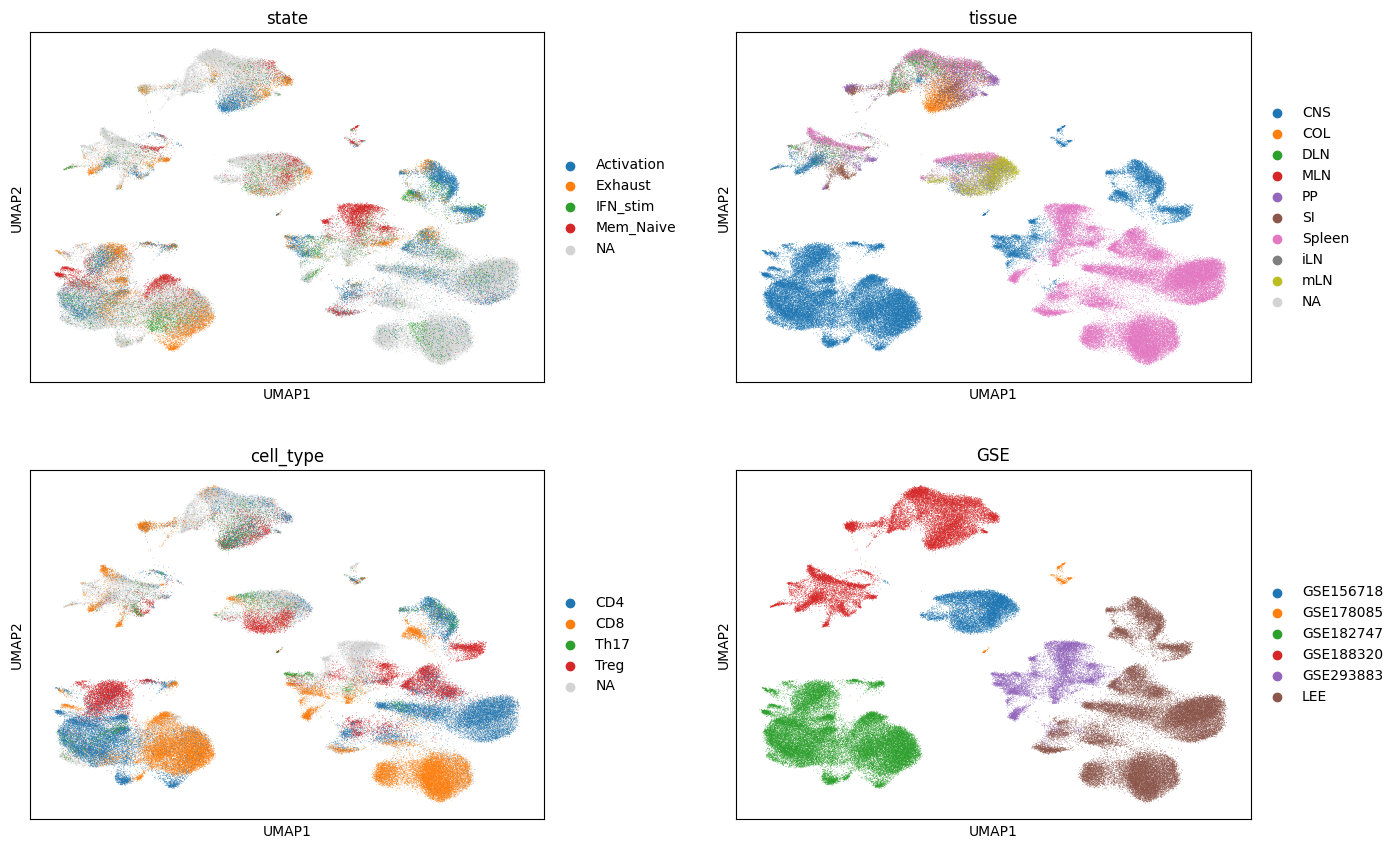

In [80]:
sc.pl.umap(merged["gex"], color=['state', 'tissue', 'cell_type', 'GSE'], ncols=2, wspace=0.25)

In [81]:
merged['gex'].obs['GSE']

AAGGTGTAGCCCAACG-1_0516_CNS          LEE
AAGTAGCAGATAGGCG-1_0516_CNS          LEE
AAGTATACACCCAGTA-1_0516_CNS          LEE
AAGTTTGGTGGAACCC-1_0516_CNS          LEE
AATCTAGGTCAAACGT-1_0516_CNS          LEE
                                 ...    
GTTGTGCAGCACGCCA-1-SPLEEN      GSE293883
GTTGTGCAGCATATGT-1-SPLEEN      GSE293883
GTTGTGCAGCGTACCG-1-SPLEEN      GSE293883
GTTGTGCAGCTTCGTT-1-SPLEEN      GSE293883
GTTGTGGGTCATTCCA-1-SPLEEN      GSE293883
Name: GSE, Length: 125524, dtype: category
Categories (6, string): [GSE156718, GSE178085, GSE182747, GSE188320, GSE293883, LEE]

### harmony correction

In [82]:
X = np.asarray(merged["gex"].obsm['X_pca'], dtype=np.float64)
bad = ~np.isfinite(X).all(axis=1)
if bad.any():
    merged["gex"] = merged["gex"][~bad].copy()
    X = np.asarray(merged["gex"].obsm['X_pca'], dtype=np.float64)
merged["gex"].obsm['X_pca'] = np.ascontiguousarray(X)

# merged["gex"].obsm['X_pca'] = np.asarray(merged["gex"].obsm['X_pca'], dtype=np.float64)
# merged["gex"].obs['GSE'] = merged["gex"].obs['GSE'].astype("string").fillna("unknown").astype("category")
merged["gex"].obs['GSE'] = merged["gex"].obs['GSE'].astype("object").astype("category")

In [83]:
## Batch correction
import scanpy.external as sce
sce.pp.harmony_integrate(merged["gex"], key=["GSE", 'sample_id'],  basis='X_pca',
                          theta = 3, lamb = 1,  sigma=0.1, nclust = 50, tau=1)

# https://github.com/slowkow/harmonypy/blob/master/harmonypy/harmony.py
# Integration Control Parameters:
# theta: Diversity clustering penalty parameter. A higher value encourages more diverse clusters.
# lamb: Ridge regression penalty parameter. Controls the strength of the regularization applied during the integration step.
# sigma: Width of soft k-means clusters. Influences the fuzziness of cluster assignments.
# nclust: Number of clusters in the model. If None, Harmony will estimate this number.
# tau: Protection against overclustering small datasets with large ones.

# Convergence and Iteration Parameters:
# max_iter_harmony: Maximum number of iterations for the Harmony algorithm if not converged.
# max_iter_cluster: Maximum number of iterations for the k-means clustering step within each Harmony iteration.
# epsilon_harmony: Convergence threshold for the Harmony objective function.
# epsilon_cluster: Convergence threshold for the k-means clustering objective function.
# plot_convergence: Boolean indicating whether to plot the convergence of the objective function. 
# verbose: Boolean indicating whether to print progress messages during execution.
# Other Parameters:
# block_size: Size of data blocks to process if using a block-wise approach.
# reference_values: Optional dictionary specifying reference values for vars_use.
# return_object: Boolean indicating whether to return the full Harmony model object or just the corrected embeddings.

2025-11-30 19:15:39,739 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-11-30 19:15:45,116 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-11-30 19:15:45,324 - harmonypy - INFO - Iteration 1 of 10
2025-11-30 19:16:00,887 - harmonypy - INFO - Iteration 2 of 10
2025-11-30 19:16:15,633 - harmonypy - INFO - Iteration 3 of 10
2025-11-30 19:16:30,851 - harmonypy - INFO - Iteration 4 of 10
2025-11-30 19:16:46,139 - harmonypy - INFO - Iteration 5 of 10
2025-11-30 19:17:01,808 - harmonypy - INFO - Iteration 6 of 10
2025-11-30 19:17:15,460 - harmonypy - INFO - Iteration 7 of 10
2025-11-30 19:17:30,386 - harmonypy - INFO - Iteration 8 of 10
2025-11-30 19:17:42,923 - harmonypy - INFO - Iteration 9 of 10
2025-11-30 19:17:57,250 - harmonypy - INFO - Converged after 9 iterations


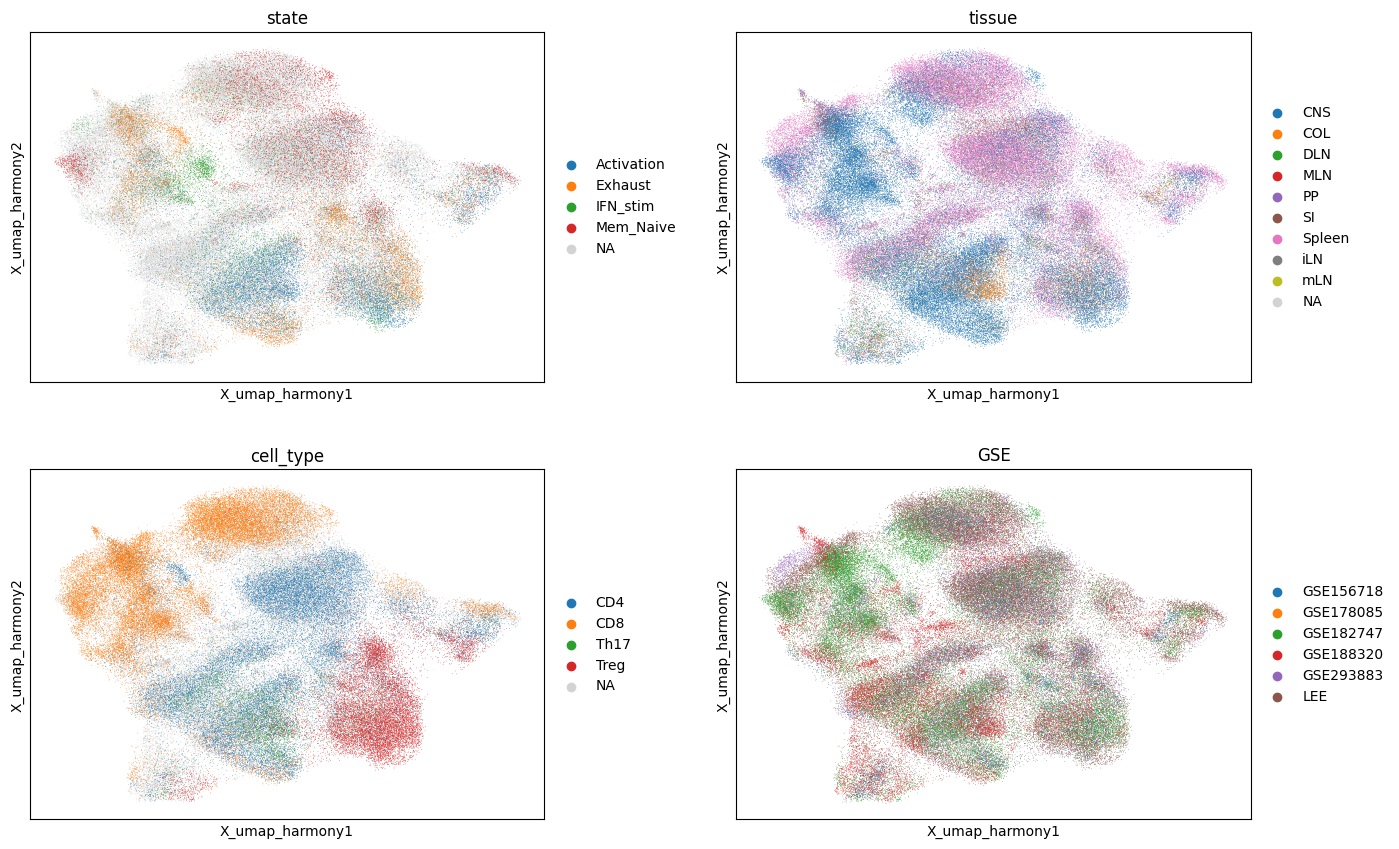

In [84]:
sc.pp.neighbors(merged["gex"], n_neighbors = 30, use_rep='X_pca_harmony', key_added = 'neighbors_harmony')
sc.tl.umap(merged["gex"], min_dist=0.5, spread=1.0, neighbors_key = 'neighbors_harmony', key_added = 'X_umap_harmony')
sc.pl.embedding(merged["gex"], basis = 'X_umap_harmony', neighbors_key = 'neighbors_harmony', 
                color=['state', 'tissue', 'cell_type', 'GSE'], ncols=2, wspace=0.25)

## ingest all sets to one reference set

In [85]:
# # Use LEE as reference and map the rest using sc.tl.ingest
# # Split into reference (LEE) and query (rest)
# ref_mask = mdata.obs['GSE'] == 'LEE'
# query_mask = ~ref_mask

# print(f"Reference (LEE) cells: {ref_mask.sum()}")
# print(f"Query cells: {query_mask.sum()}")

# # Extract reference and query datasets
# mdata_ref = mdata[ref_mask].copy()
# mdata_query = mdata[query_mask].copy()

# # Prepare reference: ensure PCA is computed
# # Check if PCA exists, if not compute it
# if 'X_pca' not in mdata_ref['gex'].obsm.keys():
#     print("Computing PCA on reference dataset...")
#     sc.pp.highly_variable_genes(mdata_ref['gex'], n_top_genes=2000)
#     sc.pp.scale(mdata_ref['gex'])
#     sc.tl.pca(mdata_ref['gex'], n_comps=50)
# else:
#     print("Using existing PCA from reference dataset")

# # Prepare query: ensure it has the same preprocessing
# # Align genes between reference and query
# common_genes = mdata_ref['gex'].var_names.intersection(mdata_query['gex'].var_names)
# print(f"Common genes between reference and query: {len(common_genes)}")

# # Extract AnnData objects, subset genes, and create new MuData objects
# gex_ref = mdata_ref['gex'][:, common_genes].copy()
# gex_query = mdata_query['gex'][:, common_genes].copy()
# airr_ref = mdata_ref['airr'].copy()
# airr_query = mdata_query['airr'].copy()

# # Recreate MuData objects with subsetted genes
# mdata_ref = mu.MuData({'gex': gex_ref, 'airr': airr_ref})
# mdata_query = mu.MuData({'gex': gex_query, 'airr': airr_query})
# mdata_ref.update()
# mdata_query.update()

# # Ensure query has the same preprocessing steps
# if 'X_pca' not in mdata_query['gex'].obsm.keys():
#     print("Preprocessing query dataset...")
#     # Use the same highly variable genes as reference
#     mdata_query['gex'].var['highly_variable'] = mdata_query['gex'].var_names.isin(
#         mdata_ref['gex'].var_names[mdata_ref['gex'].var['highly_variable']]
#     )
#     sc.pp.scale(mdata_query['gex'])

# # Use sc.tl.ingest to map query to reference
# print("Mapping query to reference using sc.tl.ingest...")
# sc.tl.ingest(
#     mdata_query['gex'], 
#     mdata_ref['gex'], 
#     obs='GSE',
#     embedding_method='pca',
#     neighbors_key=None,
#     inplace=True
# )

# # Combine reference and query back together
# # Concatenate the gex modalities
# gex_combined = mdata_ref['gex'].concatenate(mdata_query['gex'], index_unique=None)

# # For airr modality, we need to maintain the same order
# # Get the combined cell order
# combined_cell_order = gex_combined.obs_names

# # Reorder airr data to match
# airr_ref = mdata_ref['airr']
# airr_query = mdata_query['airr']
# airr_combined = airr_ref.concatenate(airr_query, index_unique=None)

# # Create new combined mdata
# mdata = mu.MuData({'gex': gex_combined, 'airr': airr_combined})
# mdata.update()

# print(f"Combined mdata shape: {mdata.shape}")
# print(f"GSE distribution after ingest:")
# print(mdata.obs['GSE'].value_counts())


# Save

In [88]:
import anndata as ad
ad.settings.allow_write_nullable_strings = True
save_filename = 'EAE_HV_then_merged'
merged.write(save_filename +'.h5mu')

In [87]:
# merged_test.write(save_filename +'_test.h5mu')